# Chess Stats Tutorial

This notebook walks through how to ingest your chess.com game history and explore it using the `chess_stats` query API.

**Workflow:**
1. Run the ingest script to pull game history from chess.com → stored as `data/games.parquet`
2. Load a `GameDB` and query / visualize the data
3. (Optional) Join with external data (health metrics, sleep logs, etc.) for correlation analysis

## 1. Ingest game history

Run this once (and again periodically to pick up new games). It is safe to re-run — already-fetched months are skipped.

In [ ]:
import subprocess
result = subprocess.run(
    ["uv", "run", "python", "-m", "chess_stats.ingest", "--username", "nirum11"],
    capture_output=True, text=True, cwd=".."
)
print(result.stdout)
if result.returncode != 0:
    print("STDERR:", result.stderr)

## 2. Connect to the local data

In [12]:
import sys
sys.path.insert(0, "..")

import polars as pl
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

from chess_stats import GameDB

db = GameDB("../data")

## 3. Summary statistics

In [13]:
summary = db.summary()
for k, v in summary.items():
    print(f"{k:25s}: {v}")

total_games              : 15481
win_rate                 : 0.489
wins                     : 7563
losses                   : 7325
draws                    : 593
first_game               : 2017-12-18T02:46:53+00:00
last_game                : 2026-03-05T09:26:36+00:00
usernames                : ['nirum11']
games_by_type            : {'blitz': 11273, 'rapid': 4208}
avg_my_accuracy          : 76.8


## 4. Raw game data

`db.games()` returns a polars DataFrame with one row per game. All standard polars operations apply.

In [14]:
games = db.games()
print(f"Shape: {games.shape}")
games.head(5)

Shape: (15481, 19)


game_id,username,color,opponent,my_rating,opponent_rating,result,result_detail,time_class,time_control,end_time,end_datetime,hour_of_day,day_of_week,eco_code,num_moves,my_accuracy,opponent_accuracy,fen
str,str,str,str,i32,i32,str,str,str,str,i64,str,i8,i8,str,i32,f32,f32,str
"""2495438859""","""nirum11""","""white""","""nini77""",1061,1283,"""loss""","""timeout""","""blitz""","""300""",1513565213,"""2017-12-18T02:46:53+00:00""",2,0,null,70,null,null,"""8/6kp/r3ppp1/4Q3/2P5/4P3/5PPP/…"
"""2497892256""","""nirum11""","""black""","""JayReid17""",1163,947,"""win""","""win""","""blitz""","""300""",1513675406,"""2017-12-19T09:23:26+00:00""",9,1,null,114,null,null,"""8/3p4/3p4/8/2k1b3/5p2/3q4/5K2 …"
"""2499815260""","""nirum11""","""black""","""bagnor""",1067,1218,"""loss""","""resigned""","""blitz""","""300""",1513755268,"""2017-12-20T07:34:28+00:00""",7,2,null,53,null,null,"""8/5p1N/1p1kp3/p2p4/3P4/1P2P3/P…"
"""2499820032""","""nirum11""","""white""","""Momo108""",975,1062,"""loss""","""resigned""","""blitz""","""300""",1513755605,"""2017-12-20T07:40:05+00:00""",7,2,null,34,null,null,"""r3k1nB/pp3p1p/4p3/3n4/b3q3/1K4…"
"""2500656936""","""nirum11""","""black""","""Shan7585""",1042,924,"""win""","""win""","""blitz""","""300""",1513791676,"""2017-12-20T17:41:16+00:00""",17,2,null,22,null,null,"""r6r/ppp2kbp/2n2np1/3Pp3/4P3/8/…"


In [15]:
# Filter to rapid games only
rapid = db.games(time_class="rapid")
print(f"Rapid games: {len(rapid)}")
rapid.head(3)

Rapid games: 4208


game_id,username,color,opponent,my_rating,opponent_rating,result,result_detail,time_class,time_control,end_time,end_datetime,hour_of_day,day_of_week,eco_code,num_moves,my_accuracy,opponent_accuracy,fen
str,str,str,str,i32,i32,str,str,str,str,i64,str,i8,i8,str,i32,f32,f32,str
"""2713590971""","""nirum11""","""white""","""Themadkid""",1382,1251,"""win""","""win""","""rapid""","""1800""",1522494490,"""2018-03-31T11:08:10+00:00""",11,5,null,51,null,null,"""R5k1/2p2ppp/4p3/1r3b2/3P4/2P1P…"
"""2713620173""","""nirum11""","""black""","""Themadkid""",1214,1262,"""loss""","""resigned""","""rapid""","""1800""",1522495639,"""2018-03-31T11:27:19+00:00""",11,5,null,77,null,null,"""2Rr4/1P6/5kp1/7p/1KP5/B7/8/8 b…"
"""2739767118""","""nirum11""","""black""","""Keenan44""",1319,1196,"""win""","""win""","""rapid""","""1800""",1523520009,"""2018-04-12T08:00:09+00:00""",8,3,null,36,null,null,"""2kr2r1/2p3p1/1pQ2p1p/p2Nb3/P7/…"


## 5. Rating over time

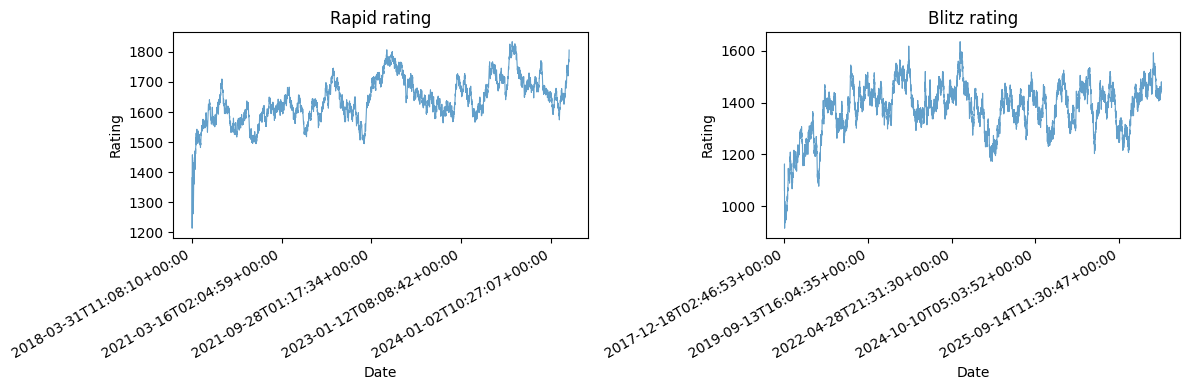

In [16]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4), sharey=False)

for ax, tc in zip(axes, ["rapid", "blitz"]):
    hist = db.rating_history(time_class=tc)
    if hist.is_empty():
        ax.set_title(f"{tc.title()} (no data)")
        continue
    dates = hist["end_datetime"].to_list()
    ratings = hist["my_rating"].to_list()
    ax.plot(dates, ratings, linewidth=0.8, alpha=0.7)
    ax.set_title(f"{tc.title()} rating")
    ax.set_xlabel("Date")
    ax.set_ylabel("Rating")
    # Show only a few x-tick labels to avoid crowding
    ax.xaxis.set_major_locator(mticker.MaxNLocator(5))
    plt.setp(ax.xaxis.get_majorticklabels(), rotation=30, ha="right")

fig.tight_layout()
plt.show()

## 6. Win rate by hour of day

This is the core hook for correlating performance with external factors. The hour is in UTC — convert to your local timezone if needed.

In [17]:
hourly = db.performance_by_hour()
hourly

The history saving thread hit an unexpected error (OperationalError('attempt to write a readonly database')).History will not be written to the database.


hour_of_day,n_games,wins,losses,draws,win_rate
i8,u32,u32,u32,u32,f64
0,584,301,259,24,0.515411
1,576,289,253,34,0.501736
2,733,369,337,27,0.503411
3,1106,534,534,38,0.482821
4,1398,679,673,46,0.485694
…,…,…,…,…,…
19,341,181,146,14,0.530792
20,485,240,230,15,0.494845
21,547,301,227,19,0.550274


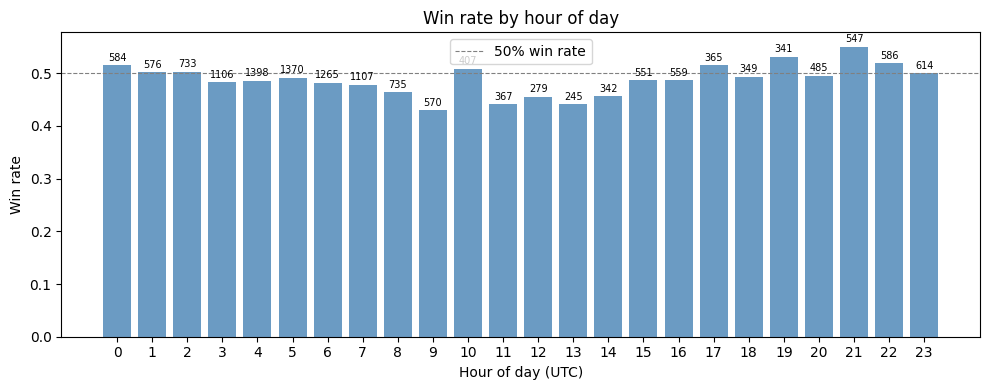

In [18]:
fig, ax = plt.subplots(figsize=(10, 4))

hours = hourly["hour_of_day"].to_list()
win_rates = hourly["win_rate"].to_list()
n_games = hourly["n_games"].to_list()

bars = ax.bar(hours, win_rates, color="steelblue", alpha=0.8)

# Annotate with game counts
for bar, n in zip(bars, n_games):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.005,
        str(n), ha="center", va="bottom", fontsize=7
    )

ax.axhline(0.5, color="gray", linestyle="--", linewidth=0.8, label="50% win rate")
ax.set_xlabel("Hour of day (UTC)")
ax.set_ylabel("Win rate")
ax.set_title("Win rate by hour of day")
ax.set_xticks(range(24))
ax.legend()
fig.tight_layout()
plt.show()

## 7. Win rate by day of week

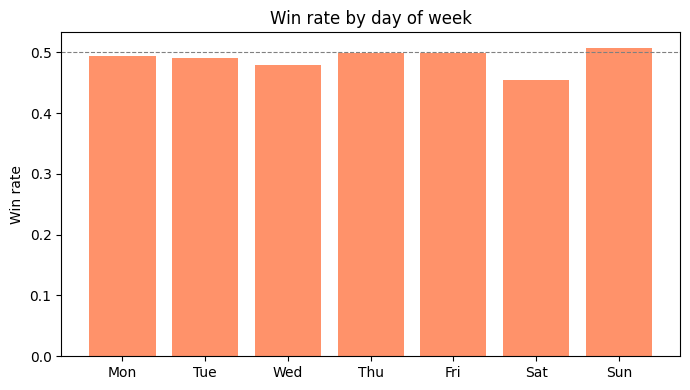

In [19]:
daily = db.performance_by_day()

fig, ax = plt.subplots(figsize=(7, 4))
ax.bar(daily["day_name"].to_list(), daily["win_rate"].to_list(), color="coral", alpha=0.85)
ax.axhline(0.5, color="gray", linestyle="--", linewidth=0.8)
ax.set_ylabel("Win rate")
ax.set_title("Win rate by day of week")
fig.tight_layout()
plt.show()

## 8. Opening analysis

In [22]:
openings = db.opening_stats(min_games=5)
print("Top openings by games played:")
openings.head(10)

Top openings by games played:


eco_code,n_games,wins,avg_my_accuracy,avg_moves,win_rate
str,u32,u32,f32,f64,f64


In [21]:
# Best and worst openings (min 10 games for reliability)
reliable = openings.filter(pl.col("n_games") >= 10)

print("Best openings (by win rate):")
print(reliable.sort("win_rate", descending=True).head(5))
print("\nWorst openings (by win rate):")
print(reliable.sort("win_rate").head(5))

Best openings (by win rate):
shape: (0, 6)
┌──────────┬─────────┬──────┬─────────────────┬───────────┬──────────┐
│ eco_code ┆ n_games ┆ wins ┆ avg_my_accuracy ┆ avg_moves ┆ win_rate │
│ ---      ┆ ---     ┆ ---  ┆ ---             ┆ ---       ┆ ---      │
│ str      ┆ u32     ┆ u32  ┆ f32             ┆ f64       ┆ f64      │
╞══════════╪═════════╪══════╪═════════════════╪═══════════╪══════════╡
└──────────┴─────────┴──────┴─────────────────┴───────────┴──────────┘

Worst openings (by win rate):
shape: (0, 6)
┌──────────┬─────────┬──────┬─────────────────┬───────────┬──────────┐
│ eco_code ┆ n_games ┆ wins ┆ avg_my_accuracy ┆ avg_moves ┆ win_rate │
│ ---      ┆ ---     ┆ ---  ┆ ---             ┆ ---       ┆ ---      │
│ str      ┆ u32     ┆ u32  ┆ f32             ┆ f64       ┆ f64      │
╞══════════╪═════════╪══════╪═════════════════╪═══════════╪══════════╡
└──────────┴─────────┴──────┴─────────────────┴───────────┴──────────┘
